<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Time%20Series%20/%20arimamodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import warnings

warnings.filterwarnings("ignore")

In [21]:
import kagglehub

path = kagglehub.dataset_download("gvyshnya/gold-future-prices")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gold-future-prices' dataset.
Path to dataset files: /kaggle/input/gold-future-prices


In [22]:
import pandas as pd

df = pd.read_csv("/kaggle/input/gold-future-prices/future-gc00-daily-prices.csv")
df.head()

,Date,Open,High,Low,Close
0,01/02/2013,"1,676.40","1,695.40","1,670.90","1,688.80"
1,01/02/2014,"1,204.50","1,230.80","1,202.50","1,225.20"
2,01/02/2015,"1,184.00","1,194.90","1,167.30","1,186.20"
3,01/02/2018,"1,305.30","1,320.40","1,304.60","1,316.10"
4,01/02/2019,"1,285.00","1,291.00","1,280.60","1,284.10"


In [23]:
df['Date'] = pd.to_datetime(df["Date"])
df.head()

,Date,Open,High,Low,Close
0,2013-01-02,"1,676.40","1,695.40","1,670.90","1,688.80"
1,2014-01-02,"1,204.50","1,230.80","1,202.50","1,225.20"
2,2015-01-02,"1,184.00","1,194.90","1,167.30","1,186.20"
3,2018-01-02,"1,305.30","1,320.40","1,304.60","1,316.10"
4,2019-01-02,"1,285.00","1,291.00","1,280.60","1,284.10"


In [24]:
df = df.set_index('Date')
df = df.sort_index()
df.head()

,Open,High,Low,Close
Date,,,,
2009-04-24,905.50,915.40,904.20,914.10
2009-04-27,915.00,919.70,905.80,908.20
2009-04-28,907.20,907.70,884.60,893.60
2009-04-29,894.00,904.00,888.30,900.50
2009-04-30,898.60,900.80,880.10,891.20


In [25]:
filter_df = df.loc['2009':'2011']
filter_df.head()

,Open,High,Low,Close
Date,,,,
2009-04-24,905.50,915.40,904.20,914.10
2009-04-27,915.00,919.70,905.80,908.20
2009-04-28,907.20,907.70,884.60,893.60
2009-04-29,894.00,904.00,888.30,900.50
2009-04-30,898.60,900.80,880.10,891.20


In [26]:
len(filter_df)

679

In [27]:
ts = filter_df['Close']
ts

,Close
Date,
2009-04-24,914.10
2009-04-27,908.20
2009-04-28,893.60
2009-04-29,900.50
2009-04-30,891.20
...,...
2011-12-23,"1,606.00"
2011-12-27,"1,595.50"
2011-12-28,"1,564.10"


In [28]:
ts = ts.replace(',','', regex=True)
ts

,Close
Date,
2009-04-24,914.10
2009-04-27,908.20
2009-04-28,893.60
2009-04-29,900.50
2009-04-30,891.20
...,...
2011-12-23,1606.00
2011-12-27,1595.50
2011-12-28,1564.10


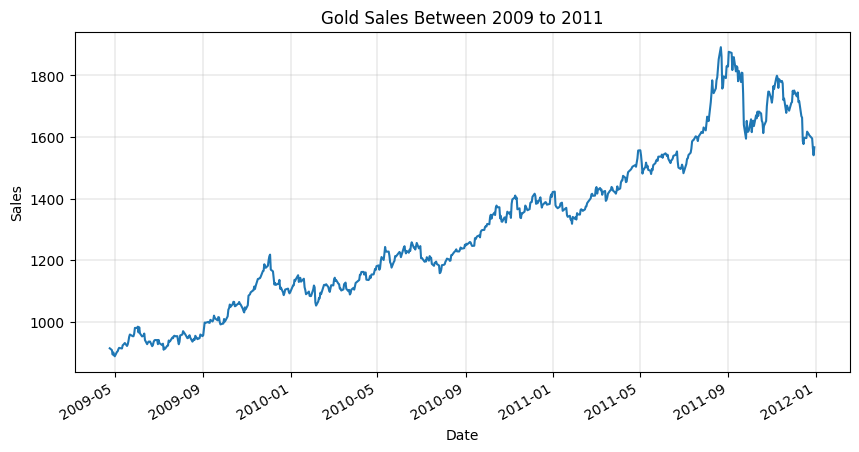

In [35]:
import matplotlib.pyplot as plt

ts = pd.to_numeric(ts)
ts.plot(figsize=(10, 5), linewidth=1.5)
plt.grid(linestyle='-', linewidth=0.3)
plt.title('Gold Sales Between 2009 to 2011')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

In [37]:
from statsmodels.tsa.stattools import adfuller

results = adfuller(ts)
results

(np.float64(-1.2139077052843363),
 np.float64(0.6675845373922201),
 10,
 668,
 {'1%': np.float64(-3.4401772556197705),
  '5%': np.float64(-2.865876419242622),
  '10%': np.float64(-2.569079289056617)},
 np.float64(5546.526047834148))

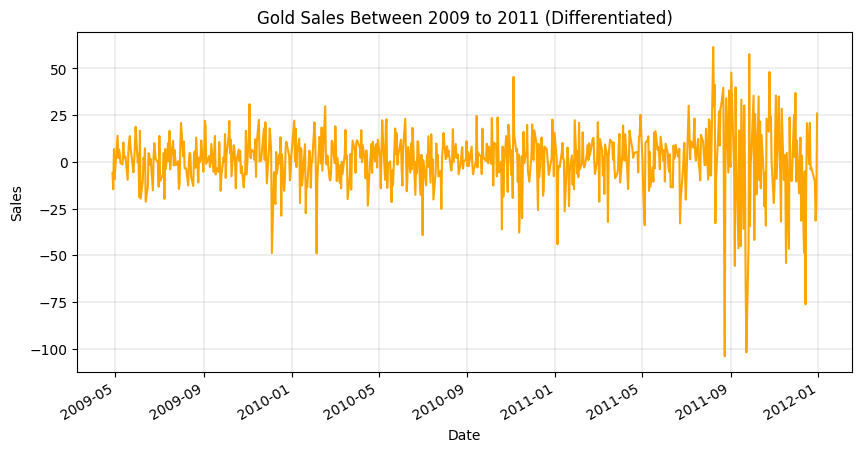

In [38]:
ts_diff = ts.diff()
ts_diff.plot(figsize=(10, 5), linewidth=1.5, color='orange')
plt.grid(linestyle='-', linewidth=0.3)
plt.title('Gold Sales Between 2009 to 2011 (Differentiated)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

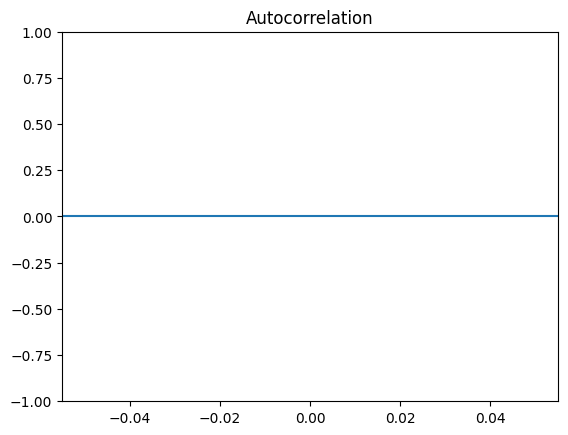

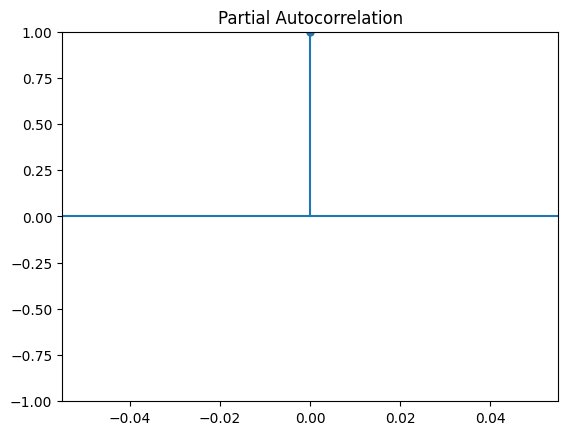

In [40]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ts_diff, lags=40)
plot_pacf(ts_diff, lags=40)
plt.show()

In [58]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts, order=(1, 1, 1))
model_fit = model.fit()

In [59]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  679
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2856.664
Date:                Wed, 22 Apr 2026   AIC                           5719.327
Time:                        13:44:43   BIC                           5732.885
Sample:                             0   HQIC                          5724.576
                                - 679                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8689      0.059    -14.760      0.000      -0.984      -0.754
ma.L1          0.9207      0.044     20.783      0.000       0.834       1.008
sigma2       267.4023      7.548     35.428      0.0

In [60]:
ts

,Close
Date,
2009-04-24,914.1
2009-04-27,908.2
2009-04-28,893.6
2009-04-29,900.5
2009-04-30,891.2
...,...
2011-12-23,1606.0
2011-12-27,1595.5
2011-12-28,1564.1


In [61]:
pred_seq = ts[len(ts) - 30: len(ts) - 1]
pred_seq

,Close
Date,
2011-11-17,1720.2
2011-11-18,1725.1
2011-11-21,1678.6
2011-11-22,1702.4
2011-11-23,1695.9
2011-11-25,1685.7
2011-11-28,1710.8
2011-11-29,1713.4
2011-11-30,1750.3


In [62]:
len(pred_seq)

29

In [63]:
pred = model_fit.predict(start=pred_seq.index[0], end=pred_seq.index[-1])
pred

,predicted_mean
Date,
2011-11-17,1770.518575
2011-11-18,1720.876922
2011-11-21,1724.730771
2011-11-22,1676.529217
2011-11-23,1705.540523
2011-11-25,1692.671434
2011-11-28,1688.143837
2011-11-29,1709.851163
2011-11-30,1714.408419


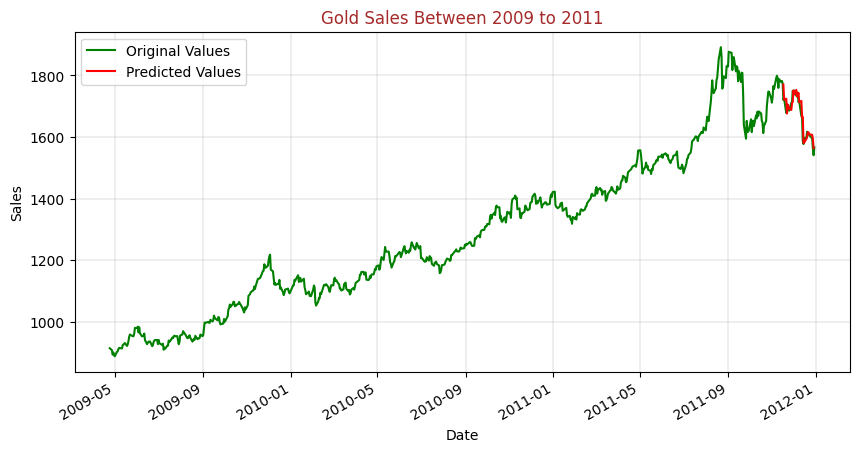

In [68]:
ts = pd.to_numeric(ts)
ts.plot(figsize=(10, 5), linewidth=1.5, color='green', label='Original Values')
pred.plot(figsize=(10, 5), linewidth=1.5, color='red', label='Predicted Values')
plt.grid(linestyle='-', linewidth=0.3)
plt.title('Gold Sales Between 2009 to 2011', color='brown')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [66]:
forecast = model_fit.forecast(steps=30)
forecast

,predicted_mean
679,1569.227384
680,1567.118258
681,1568.950853
682,1567.358533
683,1568.742081
684,1567.539932
685,1568.584466
686,1567.676883
687,1568.465471
688,1567.780276


In [72]:
last_date = ts.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(days=1), periods=len(forecast), freq='D')
forecast.index = forecast_index
forecast

,predicted_mean
2011-12-31,1569.227384
2012-01-01,1567.118258
2012-01-02,1568.950853
2012-01-03,1567.358533
2012-01-04,1568.742081
2012-01-05,1567.539932
2012-01-06,1568.584466
2012-01-07,1567.676883
2012-01-08,1568.465471
2012-01-09,1567.780276


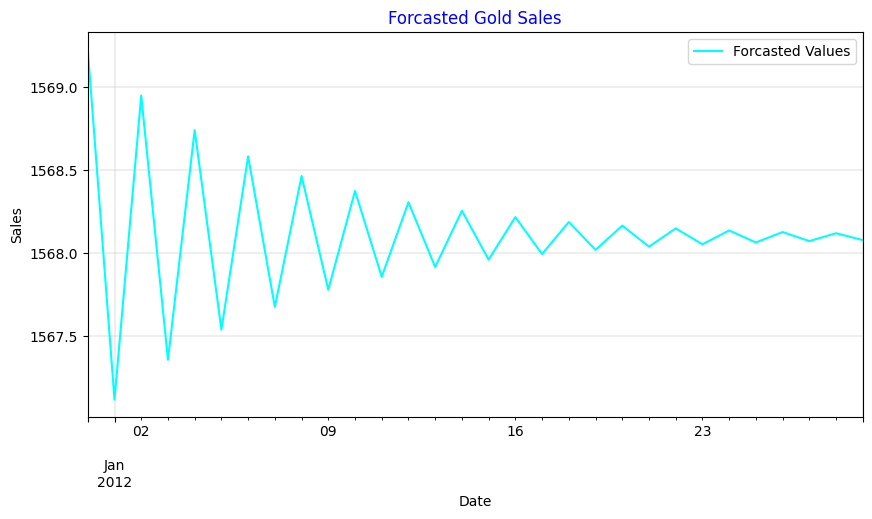

In [73]:
forecast.plot(figsize=(10, 5), linewidth=1.5, color='cyan', label='Forcasted Values')
plt.grid(linestyle='-', linewidth=0.3)
plt.title('Forcasted Gold Sales', color='blue')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()